In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split

In [98]:
data=pd.read_csv('loan_approval_data.csv')
data.head()
data.info()
data.isnull().sum()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


# Handelling Missing Data

In [99]:
categorical_cols=data.select_dtypes(include=['object']).columns
numerical_cols=data.select_dtypes(include=['float64',"int64","number"]).columns

In [100]:
from sklearn.impute import SimpleImputer# Importing SimpleImputer for handling missing values
cat_imputer = SimpleImputer(strategy='most_frequent')
num_imputer = SimpleImputer(strategy='mean')
data[categorical_cols] = cat_imputer.fit_transform(data[categorical_cols])
data[numerical_cols] = num_imputer.fit_transform(data[numerical_cols])
data.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EDA - exploratory data analysis


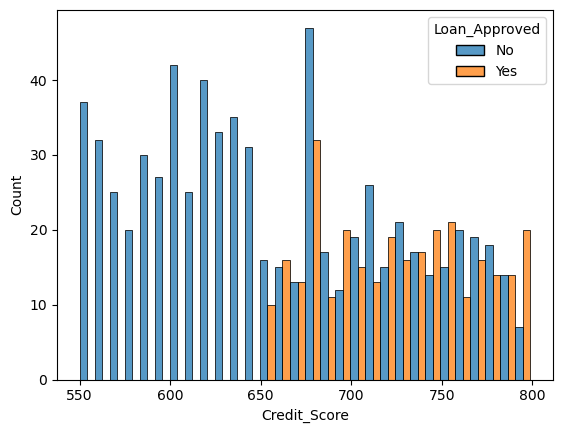

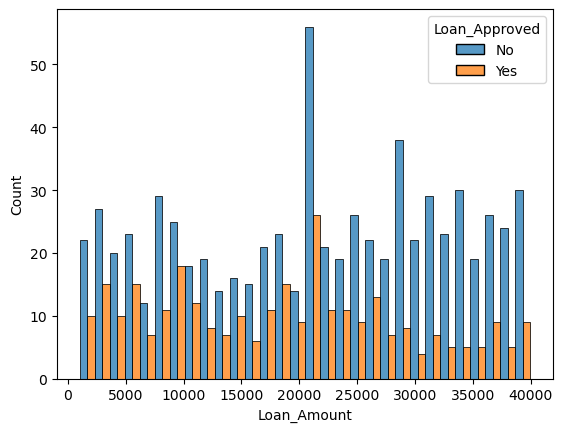

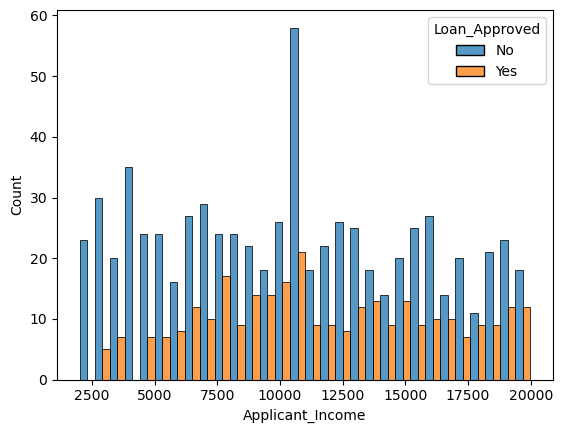

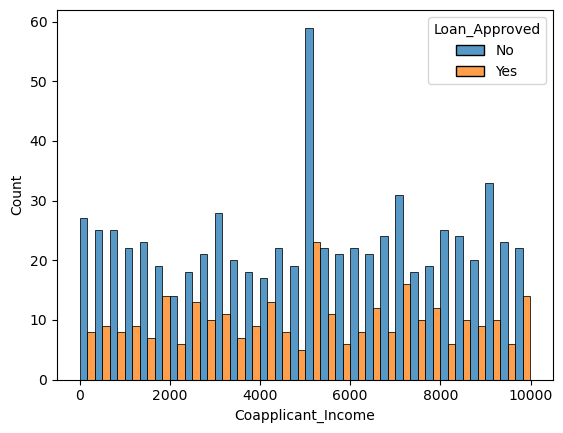

In [101]:

class_count=data['Loan_Approved'].value_counts()
# plt.pie(class_count, labels=class_count.index, autopct='%1.1f%%', startangle=90)
# plt.title('Distribution of Loan Approval')
sns.histplot(data=data, x='Credit_Score', hue='Loan_Approved', multiple='dodge', bins=30)
plt.show()
sns.histplot(data=data, x='Loan_Amount', hue='Loan_Approved', multiple='dodge', bins=30)
plt.show()
sns.histplot(data=data, x='Applicant_Income', hue='Loan_Approved', multiple='dodge', bins=30)
plt.show()
sns.histplot(data=data, x='Coapplicant_Income', hue='Loan_Approved', multiple='dodge', bins=30)
plt.show()


# feature encoding

In [102]:
from sklearn.preprocessing import LabelEncoder
from  sklearn.preprocessing import OneHotEncoder
le=LabelEncoder()
ohe= OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False)
colls=["Employment_Status","Marital_Status","Property_Area","Loan_Purpose","Employer_Category","Gender"]
colls2=["Loan_Approved","Education_Level"]
for x in colls2:
    data[x]=le.fit_transform(data[x])
encode=ohe.fit_transform(data[colls])
encoded_data=pd.DataFrame(encode,columns=ohe.get_feature_names_out(colls),index=data.index)   
data=pd.concat([data.drop(columns=colls),encoded_data],axis=1)    

# Correlation Heatmap

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Applicant_ID                      -0.011167
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed    

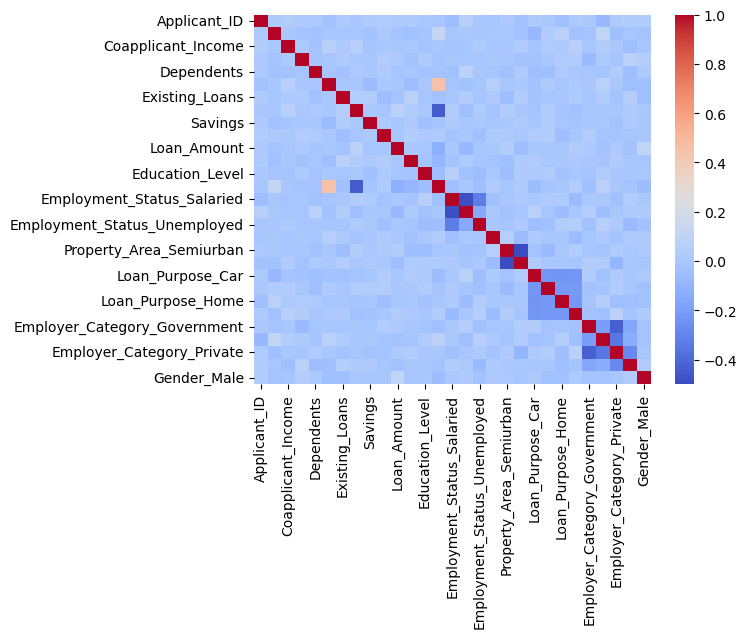

In [103]:
cols=data.select_dtypes("number")
corr_mat=cols.corr()
sns.heatmap(corr_mat,cmap="coolwarm")
corr_mat["Loan_Approved"].sort_values(ascending=False)

# Feature Scaling

In [104]:
X=data.drop(columns=["Loan_Approved"])
y=data["Loan_Approved"]
X

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Marital_Status_Single,Property_Area_Semiurban,Property_Area_Urban,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Gender_Male
0,1.0,17795.000000,1387.0,51.0,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,2.0,2860.000000,2679.0,46.0,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,3.0,7390.000000,2106.0,25.0,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,4.0,13964.000000,8173.0,40.0,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,5.0,13284.000000,4223.0,31.0,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,10852.571579,9092.0,58.0,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
996,997.0,3279.000000,6356.0,58.0,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
997,998.0,15192.000000,8433.0,48.0,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
998,999.0,9083.000000,7380.0,50.0,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


In [105]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)


In [106]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Xtrain_scaled = scaler.fit_transform(Xtrain)
Xtest_scaled = scaler.transform(Xtest)


# Trainning And Evaulation

In [107]:
#logestic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score,recall_score,f1_score, confusion_matrix, accuracy_score
model = LogisticRegression()                            
model.fit(Xtrain_scaled, ytrain)
ypred = model.predict(Xtest_scaled)
print("LogisticRegression")
print("Precision:", precision_score(ytest, ypred))
print("Recall:", recall_score(ytest, ypred))
print("F1 Score:", f1_score(ytest, ypred))
print("Confusion Matrix:\n", confusion_matrix(ytest, ypred))
print("Accuracy:", accuracy_score(ytest, ypred)) 

LogisticRegression
Precision: 0.7868852459016393
Recall: 0.7868852459016393
F1 Score: 0.7868852459016393
Confusion Matrix:
 [[126  13]
 [ 13  48]]
Accuracy: 0.87


In [108]:
#knn
from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import precision_score,recall_score,f1_score, confusion_matrix, accuracy_score
model = KNeighborsClassifier(n_neighbors=51)
model.fit(Xtrain_scaled, ytrain)
ypred = model.predict(Xtest_scaled)
print("KNN")
print("LogisticRegression")
print("Precision:", precision_score(ytest, ypred))
print("Recall:", recall_score(ytest, ypred))
print("F1 Score:", f1_score(ytest, ypred))
print("Confusion Matrix:\n", confusion_matrix(ytest, ypred))
print("Accuracy:", accuracy_score(ytest, ypred)) 

KNN
LogisticRegression
Precision: 0.8666666666666667
Recall: 0.21311475409836064
F1 Score: 0.34210526315789475
Confusion Matrix:
 [[137   2]
 [ 48  13]]
Accuracy: 0.75


In [109]:
#naive bayes
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(Xtrain_scaled, ytrain)
ypred = model.predict(Xtest_scaled)
print("Naive Bayes")
print("Precision:", precision_score(ytest, ypred))
print("Recall:", recall_score(ytest, ypred))
print("F1 Score:", f1_score(ytest, ypred))
print("Confusion Matrix:\n", confusion_matrix(ytest, ypred))
print("Accuracy:", accuracy_score(ytest, ypred)) 
#hence naive bayes is the best model for this dataset with 0.8032 precision score.

Naive Bayes
Precision: 0.8035714285714286
Recall: 0.7377049180327869
F1 Score: 0.7692307692307693
Confusion Matrix:
 [[128  11]
 [ 16  45]]
Accuracy: 0.865


# Feature Engg

In [110]:
X["DTI_Ratio_squared"]=X["DTI_Ratio"]**2
X["Credit_Score_squared"]=X["Credit_Score"]**2
X["Applicant_Income_log"]=np.log(X["Applicant_Income"]+1)
X.drop(columns=["DTI_Ratio","Credit_Score"],inplace=True)
y=data["Loan_Approved"]

In [111]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)

In [112]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Xtrain_scaled = scaler.fit_transform(Xtrain)
Xtest_scaled = scaler.transform(Xtest)

In [113]:
#logestic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score,recall_score,f1_score, confusion_matrix, accuracy_score
model = LogisticRegression()                            
model.fit(Xtrain_scaled, ytrain)
ypred = model.predict(Xtest_scaled)
print("LogisticRegression")
print("Precision:", precision_score(ytest, ypred))
print("Recall:", recall_score(ytest, ypred))
print("F1 Score:", f1_score(ytest, ypred))
print("Confusion Matrix:\n", confusion_matrix(ytest, ypred))
print("Accuracy:", accuracy_score(ytest, ypred)) 

LogisticRegression
Precision: 0.7846153846153846
Recall: 0.8360655737704918
F1 Score: 0.8095238095238095
Confusion Matrix:
 [[125  14]
 [ 10  51]]
Accuracy: 0.88


In [ ]:
#naive bayes
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(Xtrain_scaled, ytrain)
ypred = model.predict(Xtest_scaled)
print("Naive Bayes")
print("Precision:", precision_score(ytest, ypred))
print("Recall:", recall_score(ytest, ypred))
print("F1 Score:", f1_score(ytest, ypred))
print("Confusion Matrix:\n", confusion_matrix(ytest, ypred))
print("Accuracy:", accuracy_score(ytest, ypred)) 
#hence naive bayes is the best model for this dataset with 0.8076 precision score.

Naive Bayes
Precision: 0.8076923076923077
Recall: 0.6885245901639344
F1 Score: 0.7433628318584071
Confusion Matrix:
 [[129  10]
 [ 19  42]]
Accuracy: 0.855
